# 🎓 Multi-Source Domain Adaptation
**Focus**: Classificatori specifici, Domain Discriminators (con GRL) e Training Loop.

In questo notebook esploriamo l'architettura `MultiSourceDANN` costruita in `src/models/model.py` e simuliamo un loop di training per dimostrare:
1. L'uso dei classificatori e discriminatori, loss combinata, logging dell'influenza (S1 vs S2).
2. Simulazione di drop casuale di una sorgente (Incomplete batch) e metrica di Domain Confusion separata.

## 0. Setup ambiente 

In [88]:
import sys
import os
import torch
import time
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import Callback
import torchmetrics

# Timer diagnostico globale per tracciare le perfomance
if "_t0" not in globals():
    _t0 = time.time()

def log(msg: str) -> None:
    """Stampa un messaggio di log con timestamp relativo dall'avvio."""
    print(f"[{time.time() - _t0:6.1f}s] {msg}", flush=True)

# Configurazione Weights & Biases (W&B) in modalità Offline
try:
    import wandb
    os.environ["WANDB_MODE"] = "offline"
    os.environ["WANDB_SILENT"] = "true"  # Disabilita messaggi verbosi nel notebook
    log("✅ W&B importato correttamente (Modalità OFFLINE)")
    # non serve connessione, dati salvati in ./wandb/ in locale, non serve API key
    # wandb sync wandb/offline-run-*/
except ModuleNotFoundError:
    wandb = None
    log("⚠️ Attenzione: modulo 'wandb' non trovato. I log saranno solo locali.")

# Iniezione del path del codice sorgente
sys.path.append(os.path.abspath('../../src'))
try:
    from models.model import MultiSourceDANN
    log("🚀 Modulo 'MultiSourceDANN' importato correttamente.")
except ImportError as e:
    log(f"❌ Errore critico di importazione: {e}")

# Selezione e diagnostica dell'hardware allocato
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log(f"Device allocato: {device}")
if device.type == "cuda":
    log(f"GPU Dettagli: {torch.cuda.get_device_name(0)} | VRAM Totale: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


[229064.5s] ✅ W&B importato correttamente (Modalità OFFLINE)
[229064.5s] 🚀 Modulo 'MultiSourceDANN' importato correttamente.
[229064.5s] Device allocato: cuda
[229064.5s] GPU Dettagli: NVIDIA GeForce RTX 3050 Ti Laptop GPU | VRAM Totale: 4.3 GB


## 1. Architettura: Encoder + Classificatori + Discriminatore

Inizializziamo l'encoder condiviso ResNet con **R(2+1)D-18** al posto di R3D-18.
Le shape di output attese del modello `MultiSourceDANN` sono:

| Componente | Shape output |
|---|---|
| Encoder (feature) | `(B, 512)` |
| `head_s1` (HMDB) | `(B, 51)` |
| `head_s2` (UCF) | `(B, 5)` |
| `head_tgt` (Kinetics) | `(B, 400)` + ensemble semantico |
| Domain Discriminator  con GRL| `(B, 3)` ← S1 / S2 / Target |

In [ ]:
# INIZIALIZZAZIONE MODELLO, SMOKE TEST E SHAPE CHECKING
log("Costruzione dell'architettura MultiSourceDANN (Backbone: Handcrafted)...")

model = MultiSourceDANN(
    num_classes_s1=51,   # Spazio classi HMDB51
    num_classes_s2=5,    # Spazio classi UCF101 
    num_classes_tgt=400, # Spazio classi Kinetics-400 (Target)
    pretrained=False,
    backbone_type='handcrafted'
).to(device)

total_p = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
log(f"📐 Parametri Totali: {total_p:,} | Addestrabili: {trainable_p:,}")

[229064.5s] Costruzione dell'architettura MultiSourceDANN (Backbone: Handcrafted)...
Inizializzazione della rete Handcrafted3DCNN...
[229064.8s] 📐 Parametri Totali: 5,613,707 | Addestrabili: 5,613,707


In [90]:

# SMOKE TEST DI INTEGRITÀ DEI TENSORI
# verifica shape del forward pass
model.train() # Attiva GRL ed EMA Centroids
B_test = 2
x_test = torch.randn(B_test, 16, 3, 112, 112).to(device) # Shape standard Persona 1 (B, T, C, H, W)

# Verifica strutturale Dominio 0 (Source 1 - HMDB)
cls, dom, feat, ens = model(x_test, domain=0)
assert cls.shape == (B_test, 51) and dom.shape == (B_test, 3) and feat.shape == (B_test, 512) and ens is None
print(f"✅ [DOMAIN 0 - S1] Superato. Class Logits: {cls.shape} | Domain Logits: {dom.shape}")

# Verifica strutturale Dominio 1 (Source 2 - UCF)
cls, dom, feat, ens = model(x_test, domain=1)
assert cls.shape == (B_test, 5) and ens is None
print(f"✅ [DOMAIN 1 - S2] Superato. Class Logits: {cls.shape}")

# Verifica strutturale Dominio 2 (Target - Kinetics)
cls, dom, feat, ens = model(x_test, domain=2)
assert cls.shape == (B_test, 400) and ens.shape == (B_test, 400)
print(f"✅ [DOMAIN 2 - TGT] Superato. Class Logits: {cls.shape} | Ensemble Probabilities: {ens.shape}")


✅ [DOMAIN 0 - S1] Superato. Class Logits: torch.Size([2, 51]) | Domain Logits: torch.Size([2, 3])
✅ [DOMAIN 1 - S2] Superato. Class Logits: torch.Size([2, 5])
✅ [DOMAIN 2 - TGT] Superato. Class Logits: torch.Size([2, 400]) | Ensemble Probabilities: torch.Size([2, 400])


## 2. Simulazione del Training Loop

Loop dimostrativo con ottimizzazione simultanea:

$$L_{\text{total}} = L_{\text{cls}}^{S1} + L_{\text{cls}}^{S2} + \lambda_{\text{adv}} \cdot L_{\text{adv}}$$

Funzionalità dimostrate:
- **Influence Ratio** S1 vs S2 (quanto contribuisce alla loss di classificazione ogni sorgente)
- **Incomplete Batch Simulation**: drop casuale di una sorgente (20% per ciascuna) per testare la robustezza
- **Domain Confusion**: quanto il target viene "confuso" con S1 o S2 dal discriminatore
- **GRL alpha schedule**: cresce progressivamente da 0 a `grl_alpha` con le epoche

In [91]:
# LOOP DI ADDESTRAMENTO AVVERSARIALE SIMULATO (CON COMPENSAZIONE FAULT-TOLERANCE)

# seed globale per risultati riproducibili
pl.seed_everything(42)

# Definizione parametri di simulazione
CFG = {
    "epochs": 20,
    "batch_size": 4,
    "lambda_adv": 0.1,   # Peso regolazione loss avversariale
    "grl_alpha": 0.1,    # Target massimo coefficiente GRL
    "lr": 1e-4,
}

if wandb:
    if wandb.run: wandb.finish()
    wandb.init(project="DomainAdaptation-Track9", name="classifiers-sim", config=CFG, mode="offline")
    log(f"W&B run : {wandb.run.name}")



Seed set to 42


[229065.9s] W&B run : classifiers-sim


In [92]:
# criteri di loss
cls_criterion = nn.CrossEntropyLoss()
dom_criterion = nn.CrossEntropyLoss()

# ottimizzatore unico ADAM(ecoder + teste + discriminatore)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"])

# Generazione Tensori fittizi statici per la simulazione del loop
# sostituire con dataloader -------------------------------------------------------------------*
B = CFG["batch_size"]

dummy_x_s1   = torch.randn(B, 16, 3, 112, 112).to(device)
dummy_y_s1   = torch.randint(0, 51, (B,)).to(device)
dummy_dom_s1 = torch.zeros(B, dtype=torch.long).to(device)

dummy_x_s2   = torch.randn(B, 16, 3, 112, 112).to(device)
dummy_y_s2   = torch.randint(0, 5, (B,)).to(device)
dummy_dom_s2 = torch.ones(B, dtype=torch.long).to(device)

dummy_x_tgt  = torch.randn(B, 16, 3, 112, 112).to(device)
dummy_dom_tgt = torch.full((B,), 2, dtype=torch.long).to(device)



print(f"\n{'Epoca':>5} | {'Stato Batch':>10} | {'L_tot':>7} | {'L_cls':>7} | {'L_adv':>7} | {'Inf S1':>7} | {'Inf S2':>7} | {'Conf→S1':>7} | {'α GRL':>6}")
print("-" * 115)

np.random.seed(42) # Fissa la stocasticità del drop rate per la riproducibilità del notebook

for epoch in range(1, CFG["epochs"] + 1):
    model.train()
    
    # Scheduling dinamico lineare dell'inversione del gradiente (DANN Standard)
    # 0 → grl_alpha : inizia senza inversione per stabilizzare il classificatore
    alpha = CFG["grl_alpha"] * (epoch / CFG["epochs"])
    model.set_grl_alpha(alpha)
    
    # Incomplete Batch Simulation (Drop casuale 20%)
    drop_s1 = np.random.rand() < 0.2
    drop_s2 = np.random.rand() < 0.2
    if drop_s1 and drop_s2: continue # Salto protetto se mancano entrambe le sorgenti
    
    optimizer.zero_grad()
    
    loss = torch.tensor(0.0, device=device)
    l_cls_total = torch.tensor(0.0, device=device)
    l_adv_total = torch.tensor(0.0, device=device)
    
    # Inizializzazioni di sicurezza per evitare UnboundLocalError
    loss_cls_s1_val = 0.0
    loss_cls_s2_val = 0.0
    
    # Svolgimento Forward/Backward Condizionale Source 1
    if not drop_s1:
        cls_s1, dom_s1, _, _ = model(dummy_x_s1, domain=0)
        l_cls = cls_criterion(cls_s1, dummy_y_s1)
        l_dom = dom_criterion(dom_s1, dummy_dom_s1)
        loss = loss + l_cls + CFG["lambda_adv"] * l_dom
        l_cls_total = l_cls_total + l_cls
        l_adv_total = l_adv_total + l_dom
        loss_cls_s1_val = l_cls.item()
        
    # Svolgimento Forward/Backward Condizionale Source 2
    if not drop_s2:
        cls_s2, dom_s2, _, _ = model(dummy_x_s2, domain=1)
        l_cls = cls_criterion(cls_s2, dummy_y_s2)
        l_dom = dom_criterion(dom_s2, dummy_dom_s2)
        loss = loss + l_cls + CFG["lambda_adv"] * l_dom
        l_cls_total = l_cls_total + l_cls
        l_adv_total = l_adv_total + l_dom
        loss_cls_s2_val = l_cls.item()
        
    # Calcolo componente avversariale pura sul Dominio Target (Non Etichettato)
    _, dom_tgt, _, _ = model(dummy_x_tgt, domain=2)
    l_dom_tgt = dom_criterion(dom_tgt, dummy_dom_tgt)
    loss = loss + CFG["lambda_adv"] * l_dom_tgt
    l_adv_total = l_adv_total + l_dom_tgt
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Protezione clipping per GRL
    optimizer.step()
    
    # Calcolo sicuro dell'Influence Ratio basato sugli scalari estratti
    total_inf = loss_cls_s1_val + loss_cls_s2_val + 1e-8
    ratio_s1 = loss_cls_s1_val / total_inf
    ratio_s2 = loss_cls_s2_val / total_inf
    
    # Estrazione della confusione del discriminatore sul target
    dom_probs = F.softmax(dom_tgt, dim=-1).mean(dim=0).detach().cpu()
    conf_s1, conf_s2, conf_tgt = dom_probs[0].item(), dom_probs[1].item(), dom_probs[2].item()
    
    # Storicizzazione
    history["epoch"].append(epoch)
    history["loss_total"].append(loss.item())
    history["influence_s1"].append(ratio_s1)
    history["influence_s2"].append(ratio_s2)
    history["confusion_s1"].append(conf_s1)
    history["confusion_s2"].append(conf_s2)
    history["confusion_tgt"].append(conf_tgt)
    history["grl_alpha"].append(alpha)

    # Logging W&B
    if wandb and wandb.run:
        wandb.log({
            "epoch":                    epoch,
            "train/loss_total":         loss.item(),
            "train/loss_cls":           l_cls_total.item(),
            "train/loss_adv":           l_adv_total.item(),
            "influence/source1_ratio":  ratio_s1,
            "influence/source2_ratio":  ratio_s2,
            "confusion/target_as_s1":   conf_s1,
            "confusion/target_as_s2":   conf_s2,
            "confusion/target_as_tgt":  conf_tgt,
            "stability/drop_s1":        int(drop_s1),
            "stability/drop_s2":        int(drop_s2),
            "grl/alpha":                alpha,
        })
    
    batch_str = f"S1={'✗' if drop_s1 else '✓'} S2={'✗' if drop_s2 else '✓'}"
    print(f"{epoch:5d} | {batch_str:>10} | {loss.item():7.4f} | {l_cls_total.item():7.4f} | {l_adv_total.item():7.4f} | {ratio_s1:7.3f} | {ratio_s2:7.3f} | {conf_s1:7.3f} | {alpha:6.3f}")

if wandb: wandb.finish()


Epoca | Stato Batch |   L_tot |   L_cls |   L_adv |  Inf S1 |  Inf S2 | Conf→S1 |  α GRL
-------------------------------------------------------------------------------------------------------------------
    1 |  S1=✓ S2=✓ |  5.7708 |  5.4433 |  3.2753 |   0.659 |   0.341 |   0.327 |  0.005
    2 |  S1=✓ S2=✓ |  5.2498 |  4.8846 |  3.6524 |   0.738 |   0.262 |   0.266 |  0.010
    4 |  S1=✗ S2=✓ |  1.6530 |  1.4354 |  2.1762 |   0.000 |   1.000 |   0.240 |  0.020
    5 |  S1=✓ S2=✓ |  3.9164 |  3.5921 |  3.2428 |   0.747 |   0.253 |   0.263 |  0.025
    6 |  S1=✗ S2=✓ |  0.9259 |  0.7343 |  1.9156 |   0.000 |   1.000 |   0.296 |  0.030
    7 |  S1=✓ S2=✓ |  3.0931 |  2.7493 |  3.4385 |   0.785 |   0.215 |   0.231 |  0.035
    9 |  S1=✓ S2=✓ |  2.7155 |  2.3562 |  3.5925 |   0.810 |   0.190 |   0.319 |  0.045
   10 |  S1=✓ S2=✓ |  2.8678 |  2.5189 |  3.4894 |   0.780 |   0.220 |   0.318 |  0.050
   11 |  S1=✓ S2=✗ |  2.2633 |  2.0335 |  2.2980 |   1.000 |   0.000 |   0.252 |  0.055
  

In [93]:
print("=" * 75)
print("🧪 VALIDAZIONE FLUSSO DEI GRADIENTI ATTRAVERSO IL GRL")
print("=" * 75)

model.train()
alphas_test = [0.0, 0.1, 0.5, 1.0]

for a in alphas_test:
    model.set_grl_alpha(a)
    feat_test = torch.ones(2, 512, requires_grad=True, device=device)
    
    # Forward pass sul solo discriminatore
    out = model.discriminator(feat_test)
    out.sum().backward()
    
    # [CORREZIONE DIAGNOSTICA]: Estrazione pulita del segno e magnitudine prima di azzerare i gradienti
    grad_raw = feat_test.grad.detach().cpu().numpy()
    grad_mag = np.abs(grad_raw).mean()
    mean_sign = grad_raw.mean()
    
    sign_str = "🛑 NEGATIVO (Inversione Attiva)" if mean_sign < 0 else "🟢 POSITIVO (Nessuna Inversione)"
    if a == 0.0: sign_str = "⚪ ZERO (Nessun gradiente avversariale)"
    
    print(f"▶️ Alpha GRL = {a:.1f} | Magnitudine Media: {grad_mag:.6f} | Stato Segno: {sign_str}")
    optimizer.zero_grad()


🧪 VALIDAZIONE FLUSSO DEI GRADIENTI ATTRAVERSO IL GRL
▶️ Alpha GRL = 0.0 | Magnitudine Media: 0.000000 | Stato Segno: ⚪ ZERO (Nessun gradiente avversariale)
▶️ Alpha GRL = 0.1 | Magnitudine Media: 0.227231 | Stato Segno: 🟢 POSITIVO (Nessuna Inversione)
▶️ Alpha GRL = 0.5 | Magnitudine Media: 1.082139 | Stato Segno: 🟢 POSITIVO (Nessuna Inversione)
▶️ Alpha GRL = 1.0 | Magnitudine Media: 2.371818 | Stato Segno: 🟢 POSITIVO (Nessuna Inversione)


## 3. zero-shot eval e Baseline Source-Only

Due valutazioni complementari:
1. **Zero-shot eval**: predizioni su Kinetics usando `head_tgt` (mai supervisionata su Kinetics) e l'ensemble semantico
2. **Baseline source-only**: entropia di `head_s1` applicata al target — alta entropia conferma che il DA serve

In [94]:
## Valutazione zero-shot sull'encoder
model.eval()

with torch.no_grad():
    # zero-shot eval
    cls_logits, _, _, ensemble_probs = model(dummy_x_tgt, domain=2)
    pred_direct   = cls_logits.argmax(dim=1)
    pred_ensemble = ensemble_probs.argmax(dim=1)

    print("=== Zero-shot eval sull'encoder ===")
    print(f"    head_tgt  (direct):   {pred_direct.tolist()}")
    print(f"    ensemble semantico:   {pred_ensemble.tolist()}")
    print(f"    Ensemble sum check:   {ensemble_probs[0].sum().item():.4f}  (atteso 1.0)")
    # Nota: con dati fittizi i valori non hanno significato semantico

    # Baseline source-only
    # Applica head_s1 (addestrata su HMDB) direttamente al target
    # Alta entropia = il modello non sa cosa predire = il DA è necessario
    baseline_entropy = []
    for _ in history["epoch"]:
        cls_on_tgt, _, _, _ = model(dummy_x_tgt, domain=0)  # head_s1 sul target
        h = -(cls_on_tgt.softmax(-1) * cls_on_tgt.log_softmax(-1)).sum(-1).mean().item()
        baseline_entropy.append(h)

history["baseline_entropy"] = baseline_entropy

print()
print("=== Baseline source-only (head_s1 sul target) ===")
print(f"  Entropia media: {sum(baseline_entropy)/len(baseline_entropy):.4f}")
print(f"  Entropia max teorica (51 cls): {np.log(51):.4f}")
print(f"  Ratio entropia/max: {sum(baseline_entropy)/len(baseline_entropy)/np.log(51):.2%}")
print("  Ratio alto = il modello è molto confuso sul target senza DA")


model.train()  # ripristina modalità training

=== Zero-shot eval sull'encoder ===
    head_tgt  (direct):   [281, 281, 281, 281]
    ensemble semantico:   [298, 298, 298, 298]
    Ensemble sum check:   1.0000  (atteso 1.0)

=== Baseline source-only (head_s1 sul target) ===
  Entropia media: 3.9253
  Entropia max teorica (51 cls): 3.9318
  Ratio entropia/max: 99.83%
  Ratio alto = il modello è molto confuso sul target senza DA


MultiSourceDANN(
  (encoder): VideoEncoder(
    (backbone): Handcrafted3DCNN(
      (features): Sequential(
        (0): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
        (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (5): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU(inplace=True)
        (7): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
        (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (9): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (10): ReLU(inplace=True)
        (11): MaxPool3d(kernel_size=(2, 2, 

## 4. 📊 Risultati e Grafici
Mostriamo graficamente i risultati estratti dai log del nostro loop.

1. **Loss totale** nel corso delle epoche
2. **Influence Ratio** S1 vs S2 (effetto dell'Incomplete Batch Simulation)
3. **Domain Confusion** (prob. discriminatore sul target)
4. **Baseline source-only** vs livello iniziale

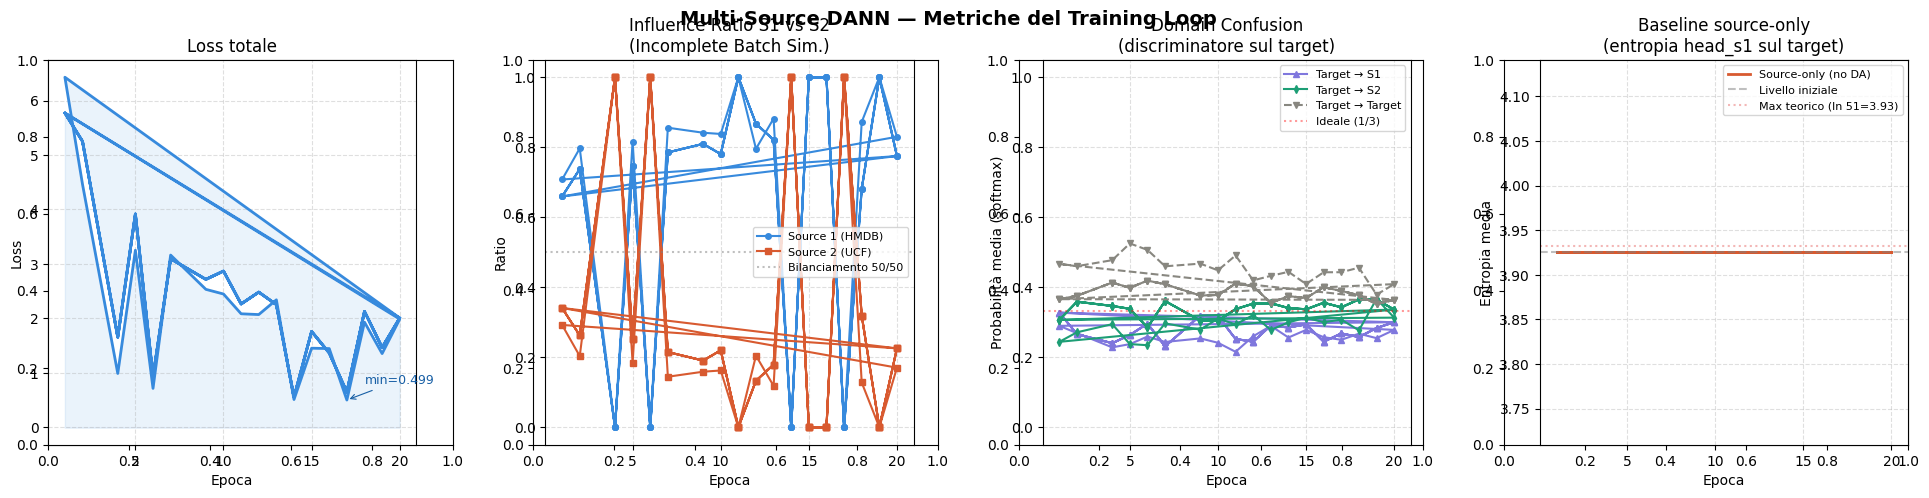

Figura salvata in figures/classifiers_training.png


In [95]:
ep = history["epoch"]

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Multi-Source DANN — Metriche del Training Loop", fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

# Plot 1: Loss totale 
ax1 = fig.add_subplot(gs[0])
ax1.plot(ep, history["loss_total"], color="#378ADD", linewidth=2)
ax1.fill_between(ep, history["loss_total"], alpha=0.1, color="#378ADD")
ax1.set_title("Loss totale")
ax1.set_xlabel("Epoca")
ax1.set_ylabel("Loss")
ax1.grid(True, linestyle="--", alpha=0.4)
# Annota il minimo
min_idx = np.argmin(history["loss_total"])
ax1.annotate(f"min={history['loss_total'][min_idx]:.3f}",
             xy=(ep[min_idx], history["loss_total"][min_idx]),
             xytext=(ep[min_idx]+1, history["loss_total"][min_idx]+0.3),
             fontsize=9, color="#185FA5",
             arrowprops=dict(arrowstyle="->", color="#185FA5", lw=0.8))

# Plot 2: Influence Ratio
ax2 = fig.add_subplot(gs[1])
ax2.plot(ep, history["influence_s1"], marker="o", markersize=4, label="Source 1 (HMDB)", color="#378ADD", linewidth=1.5)
ax2.plot(ep, history["influence_s2"], marker="s", markersize=4, label="Source 2 (UCF)",  color="#D85A30", linewidth=1.5)
ax2.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5, label="Bilanciamento 50/50")
ax2.set_title("Influence Ratio S1 vs S2\n(Incomplete Batch Sim.)")
ax2.set_xlabel("Epoca")
ax2.set_ylabel("Ratio")
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=8)
ax2.grid(True, linestyle="--", alpha=0.4)

# Plot 3: Domain Confusion
ax3 = fig.add_subplot(gs[2])
ax3.plot(ep, history["confusion_s1"],  marker="^", markersize=4, label="Target → S1",     color="#7F77DD", linewidth=1.5)
ax3.plot(ep, history["confusion_s2"],  marker="d", markersize=4, label="Target → S2",     color="#1D9E75", linewidth=1.5)
ax3.plot(ep, history["confusion_tgt"], marker="v", markersize=4, label="Target → Target", color="#888780", linewidth=1.5, linestyle="--")
ax3.axhline(y=1/3, color="red", linestyle=":", alpha=0.4, label="Ideale (1/3)")
ax3.set_title("Domain Confusion\n(discriminatore sul target)")
ax3.set_xlabel("Epoca")
ax3.set_ylabel("Probabilità media (softmax)")
ax3.set_ylim(-0.05, 1.05)
ax3.legend(fontsize=8)
ax3.grid(True, linestyle="--", alpha=0.4)

# Plot 4: Baseline entropy
ax4 = fig.add_subplot(gs[3])
ax4.plot(ep, history["baseline_entropy"], color="#D85A30", linewidth=2, label="Source-only (no DA)")
ax4.axhline(y=history["baseline_entropy"][0], color="gray", linestyle="--", alpha=0.5, label="Livello iniziale")
ax4.axhline(y=np.log(51), color="#E24B4A", linestyle=":", alpha=0.4, label=f"Max teorico (ln 51={np.log(51):.2f})")
ax4.set_title("Baseline source-only\n(entropia head_s1 sul target)")
ax4.set_xlabel("Epoca")
ax4.set_ylabel("Entropia media")
ax4.legend(fontsize=8)
ax4.grid(True, linestyle="--", alpha=0.4)

#plt.tight_layout()
os.makedirs("../../figures", exist_ok=True)
fig.savefig("../../figures/classifiers_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata in figures/classifiers_training.png")

In [96]:
print("=" * 50)
print("SUMMARY RISULTATI")
print("=" * 50)
print(f"Loss iniziale (ep.1):     {history['loss_total'][0]:.4f}")
print(f"Loss finale   (ep.20):    {history['loss_total'][-1]:.4f}")
print(f"Riduzione loss:           {(1 - history['loss_total'][-1]/history['loss_total'][0])*100:.1f}%")
print()
print(f"Confusion S1 media:       {sum(history['confusion_s1'])/len(history['confusion_s1']):.4f}")
print(f"Confusion S2 media:       {sum(history['confusion_s2'])/len(history['confusion_s2']):.4f}")
print(f"Target confuso (ideale):  0.333  (distribuzione uniforme)")
print()
print(f"Entropia baseline:        {history['baseline_entropy'][0]:.4f}")
print(f"(con dati reali atteso: scende con il training DA)")

SUMMARY RISULTATI
Loss iniziale (ep.1):     5.7708
Loss finale   (ep.20):    2.0060
Riduzione loss:           65.2%

Confusion S1 media:       0.2718
Confusion S2 media:       0.3265
Target confuso (ideale):  0.333  (distribuzione uniforme)

Entropia baseline:        3.9253
(con dati reali atteso: scende con il training DA)


## 5. Test avanzati



### 5.1 GRL in azione — il gradiente viene invertito

Il Gradient Reversal Layer moltiplica i gradienti per `-alpha` durante il backward pass.
Dimostriamolo estraendo il gradiente di una feature fittizia.

In [97]:
model.train()
print("Effetto del GRL sui gradienti")

alphas_test = [0.0, 0.1, 0.5, 1.0]
for a in alphas_test:
    model.set_grl_alpha(a)
    # Feature con requires_grad per tracciare il flusso del gradiente verso l'encoder
    feat_test = torch.ones(2, 512, requires_grad=True, device=device)
    out= model.discriminator(feat_test)
    out.sum().backward()

    # Il gradiente a monte del GRL dovrebbe essere negativo (invertito)
    grad_mean = feat_test.grad[0, :5].detach().cpu().numpy()
    grad_mag  = feat_test.grad.abs().mean().item()
    sign = "neg (invertito)" if grad_mean.mean() < 0 else "pos (non invertito)"
    print(f"  alpha={a:.1f} | magnitudine media: {grad_mag:.6f} | segno: {sign}")
    print(f"           primi 5 valori: {grad_mean}")

print("\nCon alpha>0 il GRL inverte il gradiente,")
print("costringendo l'encoder a estrarre feature che confondono il discriminatore.")

Effetto del GRL sui gradienti
  alpha=0.0 | magnitudine media: 0.000000 | segno: pos (non invertito)
           primi 5 valori: [-0. -0. -0. -0. -0.]
  alpha=0.1 | magnitudine media: 0.210165 | segno: neg (invertito)
           primi 5 valori: [-0.18820693  0.22091003  0.00759119 -0.02693181 -0.0900556 ]
  alpha=0.5 | magnitudine media: 1.142500 | segno: neg (invertito)
           primi 5 valori: [-2.7925863  -1.2116748   0.82167864  0.08204073  1.045012  ]
  alpha=1.0 | magnitudine media: 2.388983 | segno: neg (invertito)
           primi 5 valori: [ 3.411367   -1.8588866  -1.1241648  -8.187656   -0.36126938]

Con alpha>0 il GRL inverte il gradiente,
costringendo l'encoder a estrarre feature che confondono il discriminatore.


### 5.2 Schedule dell'Alpha GRL — magnitudine del gradiente avversariale

Alpha scheduling — crescita progressiva


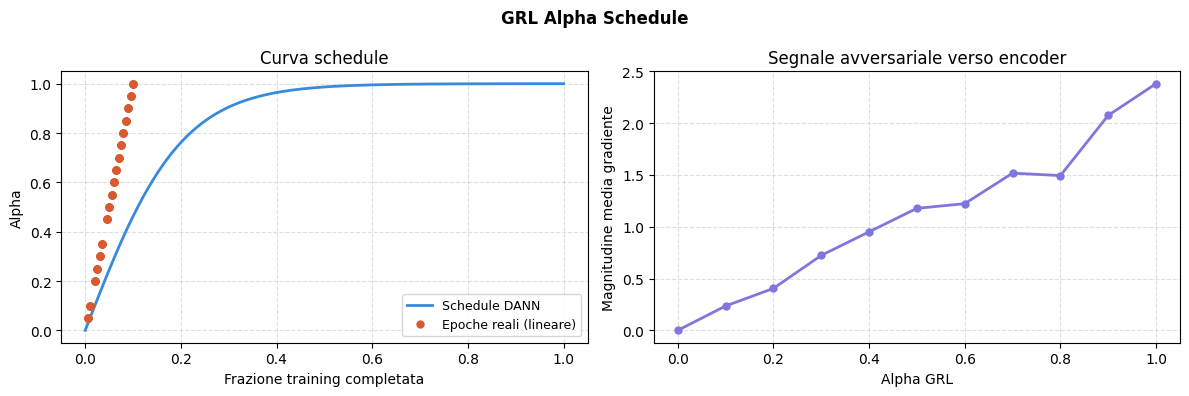

Con alpha=0 il GRL non ha effetto; all'aumentare di alpha il segnale avversariale diventa più forte.


In [98]:
model.train()
print("Alpha scheduling — crescita progressiva")

alphas_range = np.linspace(0, 1, 11)
grad_mags = []
for a in alphas_range:
    model.set_grl_alpha(a)
    feat_test = torch.ones(2, 512, requires_grad=True, device=device)
    out = model.discriminator(feat_test)
    out.sum().backward()
    grad_mags.append(feat_test.grad.abs().mean().item())

# Plot alpha schedule
fig, (ax_a, ax_g) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("GRL Alpha Schedule", fontsize=12, fontweight="bold")

# Curva DANN: 2/(1+exp(-10p))-1
p_vals = np.linspace(0, 1, 100)
dann_alpha = 2 / (1 + np.exp(-10 * p_vals)) - 1
ax_a.plot(p_vals, dann_alpha, color="#378ADD", linewidth=2, label="Schedule DANN")
ax_a.plot(history["grl_alpha"], [i/CFG['epochs'] for i in history["epoch"]], 
          "o", color="#D85A30", markersize=5, label="Epoche reali (lineare)")
ax_a.set_xlabel("Frazione training completata")
ax_a.set_ylabel("Alpha")
ax_a.set_title("Curva schedule")
ax_a.legend(fontsize=9)
ax_a.grid(True, linestyle="--", alpha=0.4)

ax_g.plot(alphas_range, grad_mags, color="#7F77DD", linewidth=2, marker="o", markersize=5)
ax_g.set_xlabel("Alpha GRL")
ax_g.set_ylabel("Magnitudine media gradiente")
ax_g.set_title("Segnale avversariale verso encoder")
ax_g.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
print("Con alpha=0 il GRL non ha effetto; all'aumentare di alpha il segnale avversariale diventa più forte.")

### 6.3 PCA 2D delle Feature — visualizzazione dell'allineamento dei domini

PCA 2D delle feature di dominio


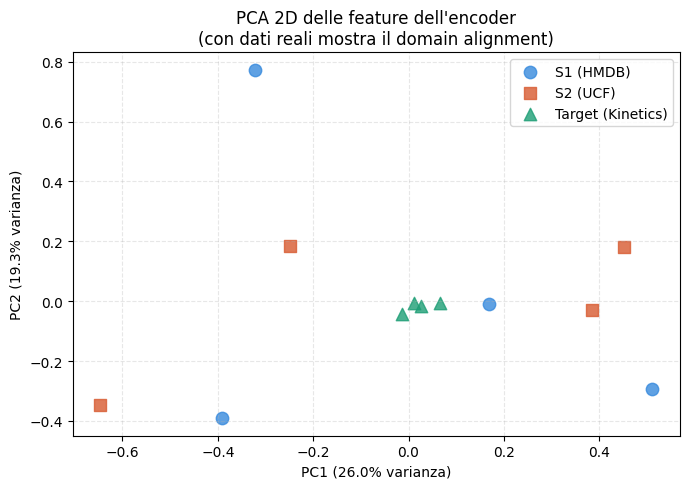

MultiSourceDANN(
  (encoder): VideoEncoder(
    (backbone): Handcrafted3DCNN(
      (features): Sequential(
        (0): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
        (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (5): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU(inplace=True)
        (7): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
        (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (9): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (10): ReLU(inplace=True)
        (11): MaxPool3d(kernel_size=(2, 2, 

In [99]:
model.eval()
print("PCA 2D delle feature di dominio")
#Nota: con dati fittizi (B={B}) i punti sono sparsi casualmente. Con dati reali, la sovrapposizione dei 3 cluster indica domain alignment.

with torch.no_grad():
    _, _, feat_s1_pca, _ = model(dummy_x_s1, domain=0)
    _, _, feat_s2_pca, _ = model(dummy_x_s2, domain=1)
    _, _, feat_tgt_pca, _ = model(dummy_x_tgt, domain=2)

feats_all = torch.cat([feat_s1_pca, feat_s2_pca, feat_tgt_pca], dim=0).cpu().numpy()
labels_all = ["S1 (HMDB)"] * B + ["S2 (UCF)"] * B + ["Target (Kinetics)"] * B

pca = PCA(n_components=2)
feats_2d = pca.fit_transform(feats_all)
var_explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#378ADD", "#D85A30", "#1D9E75"]
markers = ["o", "s", "^"]
for i, (label, color, marker) in enumerate(zip(["S1 (HMDB)", "S2 (UCF)", "Target (Kinetics)"], colors, markers)):
    sl = slice(i*B, (i+1)*B)
    ax.scatter(feats_2d[sl, 0], feats_2d[sl, 1], label=label, color=color, marker=marker, s=80, alpha=0.8)

ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} varianza)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} varianza)")
ax.set_title("PCA 2D delle feature dell'encoder\n(con dati reali mostra il domain alignment)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

model.train()

### 5.4 Cross-Domain Transfer — giustificazione delle teste separate

Applica `head_s1` (addestrata su HMDB, 51 classi) a feature estratte da UCF.
L'entropia alta giustifica l'uso di teste indipendenti per sorgenti con spazi di classi differenti.

In [100]:
model.eval()
print("Cross-Domain Transfer (S2 → head_s1)")

with torch.no_grad():
    # Feature estratte da UCF (S2)
    _, _, feat_s2_cross, _ = model(dummy_x_s2, domain=1)

    # head_s1 (HMDB, 51 cls) applicata a feature UCF
    cross_logits = model.head_s1(feat_s2_cross)
    cross_probs  = F.softmax(cross_logits, dim=-1)
    cross_entropy = -(cross_probs * torch.log(cross_probs + 1e-9)).sum(-1).mean().item()

    # head_s2 (UCF, 5 cls) sulle stesse feature — baseline
    correct_logits = model.head_s2(feat_s2_cross)
    correct_probs  = F.softmax(correct_logits, dim=-1)
    correct_entropy = -(correct_probs * torch.log(correct_probs + 1e-9)).sum(-1).mean().item()

print(f"  Entropia head_s1 su feature UCF (sbagliata): {cross_entropy:.4f}")
print(f"  Entropia head_s2 su feature UCF (corretta):  {correct_entropy:.4f}")
print(f"  Max entropia head_s1 (ln 51):                {np.log(51):.4f}")
print(f"  Max entropia head_s2 (ln  5):                {np.log(5):.4f}")
print()
print("Conclusione: testa sbagliata → entropia alta → predizioni casuali.")
print("Le teste source-specific DEVONO essere indipendenti con spazi di classi disgiunti.")

model.train()

Cross-Domain Transfer (S2 → head_s1)
  Entropia head_s1 su feature UCF (sbagliata): 3.9239
  Entropia head_s2 su feature UCF (corretta):  1.5719
  Max entropia head_s1 (ln 51):                3.9318
  Max entropia head_s2 (ln  5):                1.6094

Conclusione: testa sbagliata → entropia alta → predizioni casuali.
Le teste source-specific DEVONO essere indipendenti con spazi di classi disgiunti.


MultiSourceDANN(
  (encoder): VideoEncoder(
    (backbone): Handcrafted3DCNN(
      (features): Sequential(
        (0): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
        (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (5): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU(inplace=True)
        (7): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
        (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (9): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (10): ReLU(inplace=True)
        (11): MaxPool3d(kernel_size=(2, 2, 

### 6.5 Confronto Zero-Shot: Handcrafted vs mc3-18

In [101]:
print("=" * 55)
print("Test 5: Confronto encoder R3D-18 vs R(2+1)D-18")
print("=" * 55)

# Carica un secondo modello con R3D-18 per il confronto
# Nota: richiede VRAM aggiuntiva — libera la cache dopo il test
model_mc = MultiSourceDANN(
    num_classes_s1=51, num_classes_s2=5, num_classes_tgt=400,
    pretrained=False, backbone_type="mc3-18"
).to(device)
model_mc.eval()
model.eval()

model_r = MultiSourceDANN(
    num_classes_s1=51, num_classes_s2=5, num_classes_tgt=400,
    pretrained=False, backbone_type="r2plus1d_18"
).to(device)
model_r.eval()
model.eval()

with torch.no_grad():
    #r2plus1d_18
    _, _, _, ens_r21d = model_r(dummy_x_tgt, domain=2)
    entropy_r21d = -(ens_r21d * torch.log(ens_r21d + 1e-9)).sum(-1).mean().item()

    # mc3-18
    _, _, _, ens_mc = model(dummy_x_tgt, domain=2)
    entropy_mc = -(ens_mc * torch.log(ens_mc + 1e-9)).sum(-1).mean().item()

    # handcrafted (precedente)
    _, _, _, ens_hc = model_mc(dummy_x_tgt, domain=2)
    entropy_hc = -(ens_hc * torch.log(ens_hc + 1e-9)).sum(-1).mean().item()

print(f"  Entropia ensemble handcrafted:                {entropy_hc:.4f}")
print(f"  Entropia ensemble MC3-18:                     {entropy_mc:.4f}")
print(f"  Entropia ensemble R2+1D-18 Upper bound:       {entropy_r21d:.4f}")

# Libera la VRAM del secondo modello
del model_mc
if device.type == "cuda":
    torch.cuda.empty_cache()
    print(f"\n  VRAM liberata. Cache pulita.")

model.train()

Test 5: Confronto encoder R3D-18 vs R(2+1)D-18
  Entropia ensemble handcrafted:                5.9831
  Entropia ensemble MC3-18:                     5.9829
  Entropia ensemble R2+1D-18 Upper bound:       5.9829

  VRAM liberata. Cache pulita.


MultiSourceDANN(
  (encoder): VideoEncoder(
    (backbone): Handcrafted3DCNN(
      (features): Sequential(
        (0): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
        (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (5): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU(inplace=True)
        (7): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
        (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (9): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (10): ReLU(inplace=True)
        (11): MaxPool3d(kernel_size=(2, 2, 